In [2]:
import numpy as np
from numpy.random import randint
import matplotlib.pyplot as plt
import random
import json


In [3]:
class TicTacToe:
    def __init__(self, dimension):
        self.dimension = dimension
        self.board_size = dimension**2
        
        #game memory for each game
        self.board = np.zeros(self.board_size)
        #self.current_state = np.zeros(dimension**2) #first game state is always empty
        self.gameCache = list(tuple(np.arange(dimension**2))) #sequence of game states from initial to final state
        self.possible_moves = list(np.arange(dimension**2))#moves remining in the game 0-8
        self.taken_moves = [] #sequence of actions 0-8
        
        self.is_end_game = False
        self.winner = None

    def isDraw(self):
        #return np.count_nonzero(self.board) == (self.board_size) - 1
        return len(self.possible_moves)==0

    def hasALine(self):
        size = self.dimension
        board = self.board.reshape(size, size)
        horizontal_sums = board.sum(axis=1)
        vertical_sums = board.sum(axis=0)
        #sum along diagonal and backdiagonal of the board
        d= np.trace(board)
        bd= np.trace(np.fliplr(board))
        for i in range(self.dimension):
            h = horizontal_sums[i]
            v = vertical_sums[i]
            if any(val == size for val in (h, v, d, bd)):
                self.winner = 1
                return True
            elif any(val == -size for val in (h, v, d, bd)):
                self.winner =-1
                return True
        return False

    def isEndGame(self):
        if (self.isDraw() or self.hasALine()):
            self.is_end_game = True
            return True
        else:
            return False

    def getGameInfo(self):
        if self.is_end_game: 
            reward = self.getReward()
            return[self.getTakenMoves(), reward]


    def resetBoard(self):
        self.board = np.zeros(self.board_size)
        self.gameCache = list(np.arange(self.board_size)) #sequence of game states from initial to final state
        self.possible_moves = list(np.arange(self.board_size))#moves remaining in the game [0-8]
        self.taken_moves = [] #sequence of actions [0-8]
        
        self.is_end_game = False
        self.winner = None

    def printBoard(self):
        print(self.board.reshape(self.dimension, self.dimension))

    def placeAction(self, ID, action:int):
        self.board[action] = ID  # reflect move on tictactoe board
        self.taken_moves.append(action)
        self.possible_moves.remove(action)
        self.gameCache.append(tuple(self.board))
        #self.current_state.append((ID*action))

        
    def getReward(self):
        if(self.hasALine()):
            return 100*self.winner
        elif(self.isDraw()):
            return 5
        else:
            return 0
        
    def getState(self):
        return tuple(self.board)

    def getPossibleMoves(self):
        return self.possible_moves

    def getTakenMoves(self):
        return self.taken_moves

    def getBoardSize(self):
        return self.board_size


In [4]:
class Q_Table():
    def __init__(self, learningRate, discountFactor):
        self.Qt = {}
        self.learning_rate = learningRate
        self.discount_factor = discountFactor

    def addState(self, state):
        
        self.Qt[state] = []
    
    def addAction(self, state, act):
        self.Qt[state].append((act,0))
        
    #takes the list of tuples of action-values pairs for the state, 
    def updateQtable(self, game_states, actions, reward):
        game_states= reversed(game_states)
        actions = reversed(actions)
        next_state = None
        for state, action in zip(game_states, actions):

            #make sure both action and state are present in the Qtable
            if not self.stateInQtable(state):
                self.addState(state)
                self.addAction(state, action)
            else: 
                if not self.st_ActInQtable(action, state):
                    self.addAction(state, action)
            
            self.updateQval(state, action, next_state, reward)
            next_state = state
    
        return self.Qt
    
    def updateQval(self, state, act, n_state, reward):
        if not (n_state == None):
            next_q = max(a[1] for a in self.Qt[n_state])
            reward = 0
        else: 
            next_q = 0
        
        for a in self.Qt[state]:
            if a[0]==act: 
                current_q = float(a[1])
        
        # update q value
        temp_diff = reward + (self.discount_factor*next_q) - current_q
        updated_q = current_q + self.learning_rate*(temp_diff)
        for i, a in enumerate(self.Qt[state]):
            if a[0] == act:
                self.Qt[state][i] = (a[0], updated_q)
    #end

    
    def getQstate(self, boardstate):
        return self.Qt[boardstate]
    
    def st_ActInQtable(self, act, state):
        acts = [a[0] for a in self.Qt[state]]
        if act in acts: return True
        else: return False

    def stateInQtable(self, state):
        if state in self.Qt: return True
        else:return False


In [5]:
class Player():
    def __init__(self, ID, char, epsilon, learningRate, discountFactor):
        self.ID = ID
        self.char = char
        self.Q_table = Q_Table(learningRate, discountFactor)
        self.epsilon = epsilon
        self.current_state = None
        self.myGameCache = list(tuple(np.arange(3**2)))

    def makeMove(self, tictactoe):
        #check if the game has ended
        if (tictactoe.isEndGame()):
            info = tictactoe.getGameInfo()
            self.Q_table.updateQtable(self.myGameCache, info[0], info[1])
            return tictactoe
        
        #else
        self.myGameCache.append(tuple(tictactoe.getState()))
        self.current_state = tictactoe.getState()
        poss_mov = tictactoe.getPossibleMoves()    

        if (np.random.random() < self.epsilon and self.Q_table.stateInQtable(self.current_state)):
            #choose from qtable
            qT = self.Q_table.getQstate(self.current_state)
            best_qval = max(t[1]for t in qT)
            #list of actions with the max qvalue
            q_mov = [t[0] for t in qT if t[1]==best_qval]
            poss_qmov = list(set(poss_mov) & set(q_mov))
            if(poss_qmov):
                tictactoe.placeAction(self.ID, random.choice(poss_qmov))
                return tictactoe

        #choose random move
        tictactoe.placeAction(self.ID, random.choice(poss_mov))
        return tictactoe

    # def makeCompMove(self, tictactoe):
    #     if (tictactoe.isEndGame()):
    #         return tictactoe
    #     self.new_state, self.reward, self.action = tictactoe.placeAction(self.ID, random.choice(poss_mov))
    #     return tictactoe
    def getQ_Table(self):
        return self.Q_table.Qt
    
    def setQ_Table(self, qtable):
        self.Q_table.Qt = qtable

    def setEpsilon(self, e):
        self.epsilon = e

    def setLearningRate(self, lr):
        self.learning_rate = lr

    def setDiscountFactor(self, df):
        self.discount_factor = df

    def updateQ_Table(self, tictactoe):
        if (tictactoe.isEndGame()):
            info = tictactoe.getGameInfo()
            self.Q_table.updateQtable(self.myGameCache, info[0], info[1])


    def getID(self):
        return self.ID

    def getCurrentState(self):
        return self.current_state


In [6]:
def PreTrained():
    epsilon =0.9
    dimension = 3
    tictactoe = TicTacToe(dimension)
    AI = Player(1, "X", epsilon, 0.9, 0.9)
    NPC = Player(-1, "O", epsilon, 0.9, 0.9)
    num = 100000
    win_rate=0
    lose_rate=0
    draw_rate=0
    for episode in range(num):
        while not tictactoe.isEndGame():
            tictactoe = AI.makeMove(tictactoe)
            tictactoe = NPC.makeMove(tictactoe)
        AI.updateQ_Table(tictactoe)
        NPC.updateQ_Table(tictactoe)
        
        # Update rates
        if tictactoe.winner == AI.getID():
            win_rate+=1
        elif tictactoe.isDraw():
            draw_rate+=1
        else:
            lose_rate+=1
        
        # Reset the game for the next episode
        tictactoe.resetBoard()

    return NPC

Opp = PreTrained()


In [7]:
class DE:
    def __init__(self, C_rate, M_fact, Opp):
        self.pop = None
        self.mutatedPop = []
        self.trialPop = []
        self.pop_size = None
        self.crossover_rate = C_rate
        self.mutationFactor = M_fact
        self.popFitness = []
        self.trialFitness = []
        self.Opponent = Opp

    def Evolve(self):
        assert isinstance(self.pop, list) and all(isinstance(Q, dict) for Q in self.pop)
        self.MutationOperation()
        self.Crossover()
        for i in range(len(self.trialPop)):
            self.trialFitness.append(self.Fitness(i, self.trialPop))
        self.Selection()
        return self.pop
    
    def InitializePop(self, Agents):
        tictactoe = TicTacToe(3)
        Q_Tables =[]
        episodes = 100
        for agent in Agents:
            for episode in range(episodes):
                while not tictactoe.isEndGame():
                    tictactoe = agent.makeMove(tictactoe)
                    tictactoe = self.Opponent.makeMove(tictactoe)
                agent.updateQ_Table(tictactoe)
                tictactoe.resetBoard()
            Q_Tables.append(agent.getQ_Table())
        
        self.pop = Q_Tables
        self.pop_size = len(Q_Tables)
        for i in range(self.pop_size):
            self.popFitness.append(self.Fitness(i, self.pop))
        return 
        

    def MutationOperation(self):
        mutated_pop = [Q.copy() for Q in self.pop]
        for Qbase in mutated_pop:
            Q1, Q2= random.sample(self.pop, 2)
            #get sets of states in each Qtable and get states that are present in all tables
            intersect_states = set(Qbase.keys()) & set(Q1.keys()) & set(Q2.keys())
            for state in intersect_states:
                qb = Qbase[state]
                q1 = Q1[state]
                q2 = Q2[state]
                #print(q1)
                for i, (act, reward) in enumerate(qb):
                    if any(a==act for (a,r) in q1) and any(a==act for (a,r) in q2): 
                        reward1 = next((r for a, r in q1 if a == act), 0)
                        reward2 = next((r for a, r in q2 if a == act), 0)
                        #add factored difference of both rewards 
                        reward = reward + self.mutationFactor*(reward1 - reward2)
                        qb[i]= (act, reward)

                Qbase[state] = qb
            
        self.mutatedPop = mutated_pop
        return 

    def Crossover(self):
        fps_Q = self.FPS()
        #trial_pop = [Q.copy() for Q in self.pop]
        for trial in self.mutatedPop:
            for state in fps_Q:
                if state in trial: 
                    if(random.random()<self.crossover_rate):  trial[state] = fps_Q[state]
        self.trialPop = self.mutatedPop
        return
    
    def FPS(self):
        pop_fit = list(zip(self.pop,self.popFitness))
        pop_fit.sort(key=lambda x: x[1], reverse=True)
        # Extract the sorted fitnesses
        fs = [fit for _, fit in pop_fit]
        sumFit = sum(fs)
        norm_fs = [fit / sumFit for fit in fs]

        # Calculate the cumulative fitness values
        cum_fs = [0] + [sum(norm_fs[:i+1]) for i in range(len(norm_fs))]
        rand_flt = random.uniform(0, 1)
        p = next(i-1 for i in range(1, len(cum_fs)) if cum_fs[i-1] < rand_flt <= cum_fs[i])

        return pop_fit[p][0]
    

    def Selection(self):
        self.pop, self.popFitness = self.Tournament()


    def Tournament(self):
        pool = self.pop + self.trialPop
        poolFit = self.popFitness + self.trialFitness
        selected = []
        selectedFit =[]
        n = len(self.pop) +len(self.trialPop)
        for i in range(self.pop_size):
            ind1, ind2 = random.sample(range(n),2)
            if(poolFit[ind1]>poolFit[ind2]): 
                selected.append(pool[ind1])
                selectedFit.append(poolFit[ind1])
                del pool[ind1]
                del poolFit[ind1]
            else: 
                selected.append(pool[ind2])
                selectedFit.append(poolFit[ind2])
                del pool[ind2]
                del poolFit[ind2]
            n -=2
        return selected, selectedFit

    # def Reinforce(self, vector, trial):
    #     #Tournamnet Selection
    #     tictactoe = TicTacToe(3)
    #     q_player = Player(1, "X", 0.9, 0.9, 0.9)
    #     q_player.setQ_Table(vector)
    #     q_opp = Player(-1, "O", 0.9, 0.9, 0.9)
    #     q_opp.setQ_Table(trial)
    #     episodes=100
    #     win_q = 0
    #     win_qopp= 0
    #     draw = 0
    #     for i in range(episodes):
    #         while not tictactoe.isEndGame():
    #             tictactoe = q_player.makeMove(tictactoe)
    #             tictactoe = q_opp.makeMove(tictactoe)

    #         if tictactoe.winner == q_player.getID(): win_q += 1
    #         elif tictactoe.isDraw() : draw += 1
    #         else: win_qopp += 1
    #         tictactoe.resetBoard()

    #     if(win_q>win_qopp): return vector
    #     else: return trial

    def Fitness(self, i,pop):
        episodes =1000
        wins = 0
        loss =0
        draw =0
        fit =0
        tictactoe = TicTacToe(3)
        agent = Player(1, "X", 0.9, 0.9, 0.9)
        agent.setQ_Table(pop[i])
        for r in range(10):
            for episode in range(episodes):
                while not tictactoe.isEndGame():
                    tictactoe = agent.makeMove(tictactoe)
                    tictactoe = self.Opponent.makeMove(tictactoe)
                if tictactoe.winner == agent.getID(): wins += 1
                elif tictactoe.isDraw() : draw += 1
                else: loss += 1
                tictactoe.resetBoard()
            
            fit += (wins - loss + 0.5*draw)
            wins =0
            loss =0
            draw =0
        ave_fit = fit/10
        return ave_fit
    
    def getPopFitness(self):
        return self.popFitness



In [8]:
num_ag = 5
generations = 10
runs = 10


In [9]:

Agents =[]

for agent in range(num_ag):
    agent = Player(1, "X", 0.9, 0.5, 0.5)
    Agents.append(agent)

In [10]:
Evolver = DE( 0.25, 0.8, Opp)
Evolver.InitializePop(Agents)
print(Evolver.getPopFitness())

[-220.5, -325.3, -177.1, -331.8, -141.65]


In [11]:

#Episode+=100
Gens_fitness = []
Gens_fitness.append(Evolver.getPopFitness())
for g in range(generations-1):
    print(Evolver.getPopFitness())
    Pop = Evolver.Evolve()
    gen = Evolver.getPopFitness()
    Gens_fitness.append(gen)
    




[-220.5, -325.3, -177.1, -331.8, -141.65]
[-141.65, -220.5, -340.55, -177.1, -325.3]
[-325.3, -141.65, -177.1, -220.5, -239.4]
[-220.5, -239.4, -141.65, -177.1, -239.4]
[-177.1, -220.5, -239.4, -141.65, -239.4]
[-233.25, -141.65, -239.4, -220.5, -177.1]
[-220.5, -141.65, -177.1, -239.4, -233.25]
[-239.4, -220.5, -233.25, -239.4, -141.65]
[-239.4, -239.4, -239.4, -141.65, -220.5]


In [12]:
bestSoFar = []
aveSoFar =[]
for gen in Gens_fitness:
    bestSoFar.append(max(gen))
    ave = sum((gen))/len(gen)
    aveSoFar.append(ave)

In [12]:
print(bestSoFar)
print(aveSoFar)

[55.3, 58.7, -52.8, 53.2, -119.4, -95.7, -98.4, 54.35, -154.35, -104.2, -84.9, -120.9, -99.0, -51.7, -49.1, -61.85, -83.8, -193.85, -253.55, -231.15, -243.1, -239.2, -226.65, -197.65, -195.8, -209.3, -218.55, -218.15, -240.55, -204.6, -131.3, -214.85, -168.25, -163.6, -103.65, -223.0, -178.1, -211.4, -182.25, -173.3, -206.25, -170.35, -193.55, -192.3, -210.3, -181.8, -214.85, -205.7, -197.05, -198.15]
[-113.60999999999999, -164.815, -223.04500000000002, -226.13499999999993, -198.66500000000002, -233.95999999999998, -253.555, -176.62499999999997, -268.2, -193.755, -184.15, -207.24499999999998, -194.66500000000002, -184.99500000000003, -191.70500000000004, -169.96499999999997, -178.62499999999997, -261.53, -292.725, -271.89500000000004, -306.0, -278.36, -276.22499999999997, -251.775, -260.49000000000007, -268.675, -265.38, -260.605, -287.87, -273.93499999999995, -273.58000000000004, -249.215, -281.27, -263.355, -268.25999999999993, -266.365, -246.61999999999998, -254.08499999999998, -251

In [13]:
import matplotlib.pyplot as plt


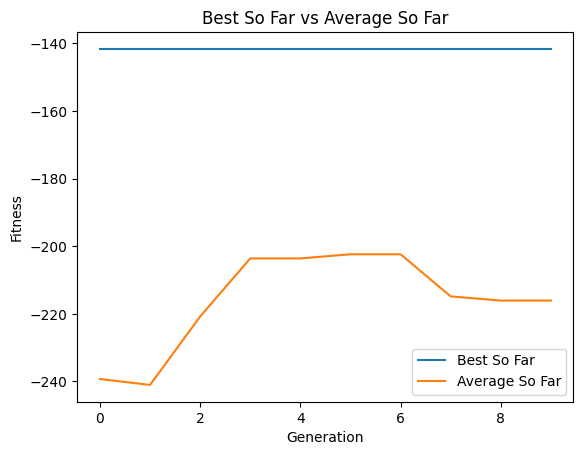

In [13]:
#before averaging 10 fitness values, for one individual
x = list(range(len(bestSoFar)))

# Plot bestSoFar
plt.plot(x, bestSoFar, label='Best So Far')

# Plot aveSoFar
plt.plot(x, aveSoFar, label='Average So Far')

# Set appropriate scales
plt.yscale('linear')  # Use linear scale for y-axis
plt.xscale('linear')  # Use linear scale for x-axis

# Add labels and title
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Best So Far vs Average So Far')

# Add legend
plt.legend()

# Show the plot
plt.show()

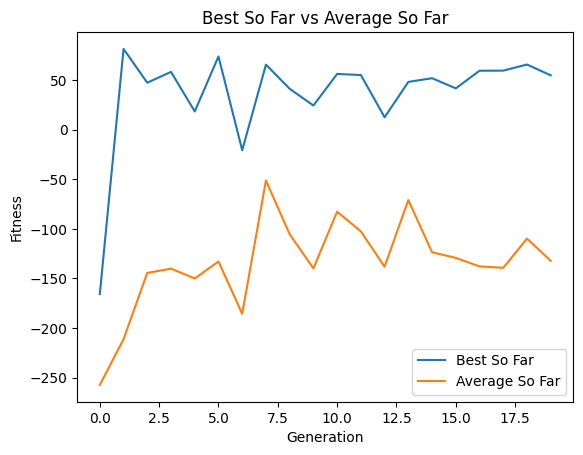

In [12]:
x = list(range(len(bestSoFar)))

# Plot bestSoFar
plt.plot(x, bestSoFar, label='Best So Far')

# Plot aveSoFar
plt.plot(x, aveSoFar, label='Average So Far')

# Set appropriate scales
plt.yscale('linear')  # Use linear scale for y-axis
plt.xscale('linear')  # Use linear scale for x-axis

# Add labels and title
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Best So Far vs Average So Far')

# Add legend
plt.legend()

# Show the plot
plt.show()

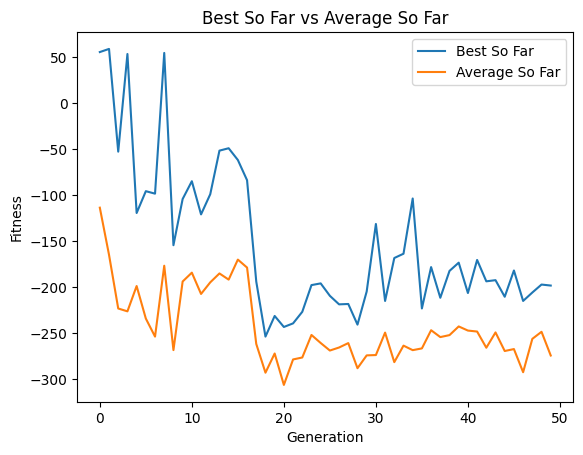

In [14]:
x = list(range(len(bestSoFar)))

# Plot bestSoFar
plt.plot(x, bestSoFar, label='Best So Far')

# Plot aveSoFar
plt.plot(x, aveSoFar, label='Average So Far')

# Set appropriate scales
plt.yscale('linear')  # Use linear scale for y-axis
plt.xscale('linear')  # Use linear scale for x-axis

# Add labels and title
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Best So Far vs Average So Far')

# Add legend
plt.legend()

# Show the plot
plt.show()